In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import src

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc("text", usetex=True)
mpl.rc("font", family="serif")

In [8]:
enoe = pd.read_parquet("outputs/enoe_harmonized.parquet")
od = pd.read_parquet("outputs/od_harmonized.parquet")

## Search for common geography

In [ ]:
enoe_common, od_common, geography_summary = src.filter_common_geography(enoe, od)

,municipio,enoe,od,common
0,guadalajara,True,True,True
1,zapopan,True,True,True
2,tlaquepaque,True,True,True
3,tlajomulco,True,True,True
4,tonala,True,True,True
5,el_salto,True,True,True
6,juanacatlan,False,True,False
7,ixtlahuacan_membrillos,True,True,True
8,zapotlanejo,False,True,False
9,tala,True,False,False


In [29]:
print(geography_summary)

                municipio   enoe     od  common
0             guadalajara   True   True    True
1                 zapopan   True   True    True
2             tlaquepaque   True   True    True
3              tlajomulco   True   True    True
4                  tonala   True   True    True
5                el_salto   True   True    True
6             juanacatlan  False   True   False
7  ixtlahuacan_membrillos   True   True    True
8             zapotlanejo  False   True   False
9                    tala   True  False   False


In [10]:
print(f"ENOE workers in common geography: {len(enoe_common):,}")
print(f"OD workers in common geography: {len(od_common):,}")
print(f"Common municipalities: {geography_summary['common'].sum()}")

ENOE workers in common geography: 5,136
OD workers in common geography: 25,053
Common municipalities: 7


## Informality benchmark

In [11]:
benchmark = src.calculate_weighted_informality_rate(enoe_common)

weighted_rate = benchmark.loc[0, "weighted_informality_rate"]
unweighted_rate = benchmark.loc[0, "unweighted_informality_rate"]

print(f"Unweighted ENOE informality rate: {unweighted_rate:.2%}")
print(f"Weighted ENOE informality rate: {weighted_rate:.2%}")

Unweighted ENOE informality rate: 39.66%
Weighted ENOE informality rate: 39.26%


## Compare ENOE and OD distributions

In [12]:
# We don't consider the “sector” attribute because it requires a more detailed analysis
predictor_columns = ["genero", "ocupacion", "edad_cat", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat"]
distribution_comparison = src.compare_weighted_distributions(enoe_common, od_common, predictor_columns)

In [13]:
distribution_comparison.reindex(distribution_comparison["difference_pp"].abs().sort_values(ascending=False).index).head(20)

,variable,category,enoe_population,od_population,enoe_share,od_share,difference_pp
15,escolaridad,no_especificado,683,353411,0.00028,0.157531,15.725135
17,escolaridad,primaria_o_secundaria,1013764,606491,0.415273,0.27034,-14.493242
26,estado_civil,casado,932228,1021169,0.381873,0.455181,7.330811
30,estado_civil,soltero,906350,702902,0.371272,0.313315,-5.795724
5,ocupacion,trabajador,1963491,1934134,0.804314,0.86213,5.78167
9,edad_cat,25_49,1380318,1396808,0.565426,0.62262,5.719416
25,municipio,zapopan,612464,673434,0.250886,0.30018,4.929338
2,ocupacion,independiente,424174,289963,0.173756,0.12925,-4.450677
0,genero,F,1049272,873248,0.429818,0.389246,-4.057216
1,genero,H,1391929,1370188,0.570182,0.610754,4.057216


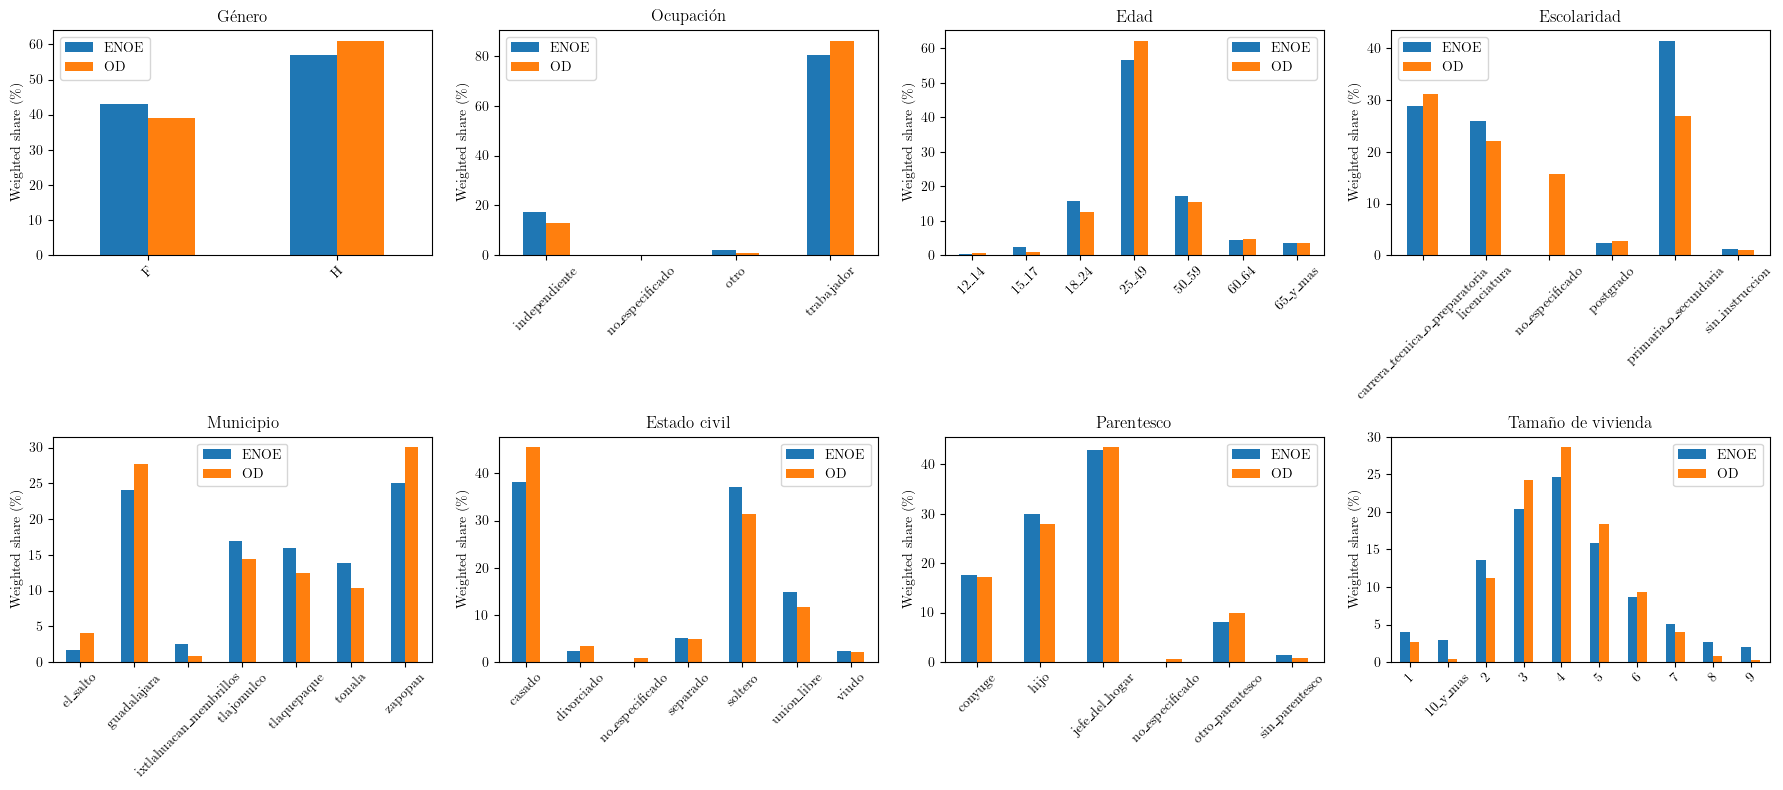

In [17]:
variables = ["genero", "ocupacion", "edad_cat", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat"]

plot_titles = {
    "genero": "Género",
    "ocupacion": "Ocupación",
    "edad_cat": "Edad",
    "escolaridad": "Escolaridad",
    "municipio": "Municipio",
    "estado_civil": "Estado civil",
    "parentesco": "Parentesco",
    "tamano_viv_cat": "Tamaño de vivienda"
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, variable in zip(axes.flatten(), variables):
    plot_data = distribution_comparison[distribution_comparison["variable"] == variable].copy()
    plot_data = plot_data.set_index("category")[["enoe_share", "od_share"]] * 100
    plot_data.plot(kind="bar", ax=ax)
    ax.set_title(plot_titles[variable])
    ax.set_xlabel("")
    ax.set_ylabel("Weighted share (\%)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(["ENOE", "OD"])

plt.tight_layout()
plt.show()

## ENOE informality per predictor

In [18]:
informality_columns = ["genero", "ocupacion", "edad_cat", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat", "sector"]
informality_profiles = src.calculate_informality_profiles(enoe_common, informality_columns)

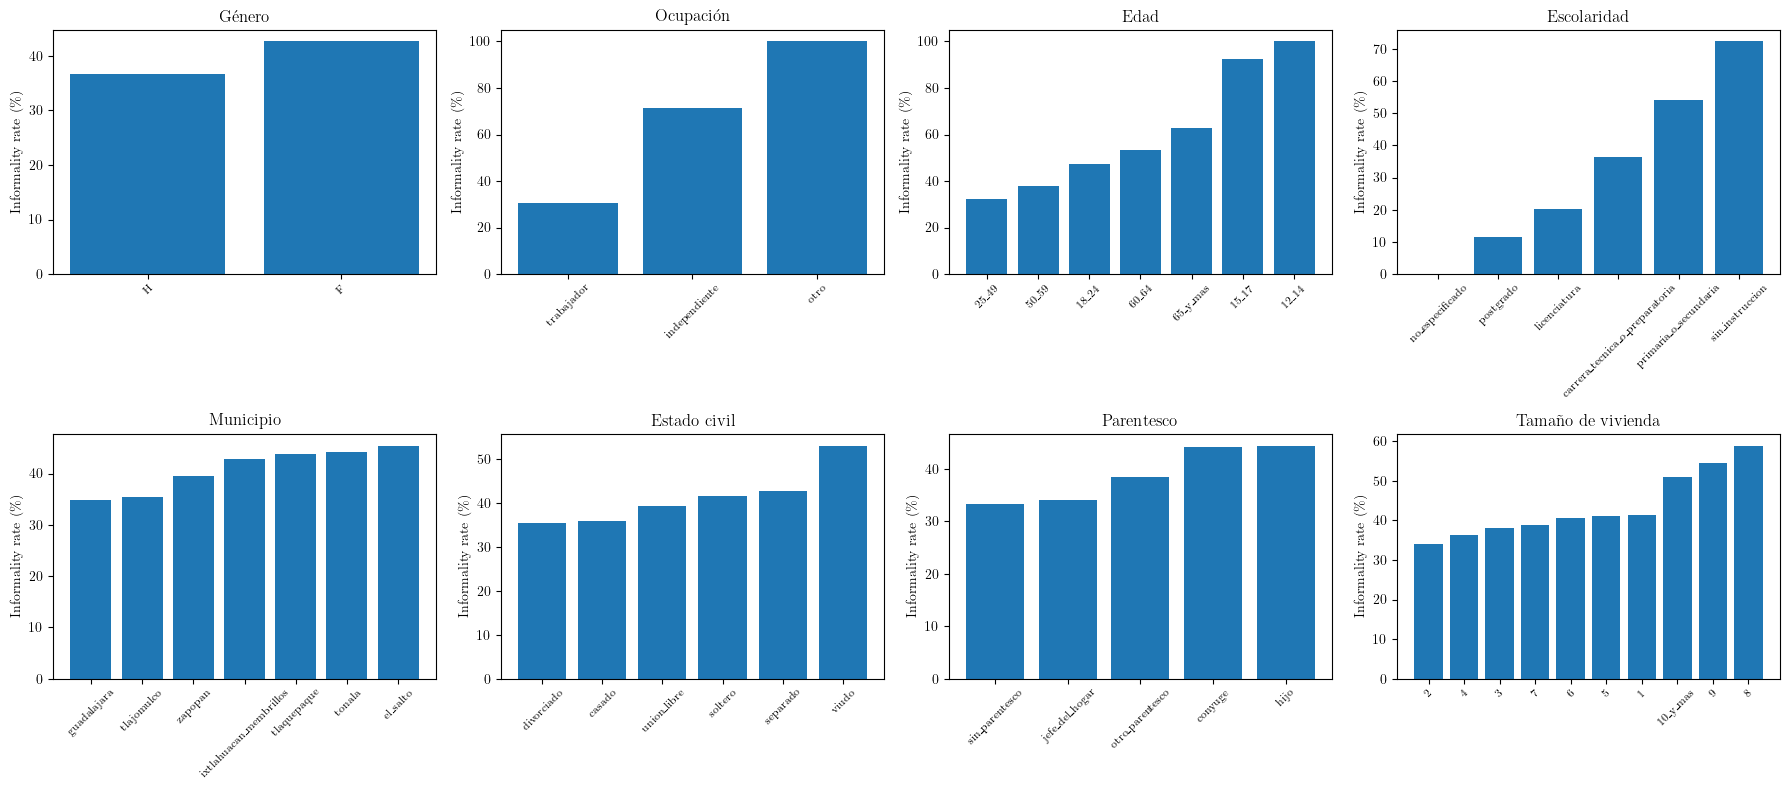

In [22]:
variables = ["genero", "ocupacion", "edad_cat", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat"]

plot_titles = {
    "genero": "Género",
    "ocupacion": "Ocupación",
    "edad_cat": "Edad",
    "escolaridad": "Escolaridad",
    "municipio": "Municipio",
    "estado_civil": "Estado civil",
    "parentesco": "Parentesco",
    "tamano_viv_cat": "Tamaño de vivienda"
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, variable in zip(axes.flatten(), variables):
    plot_data = informality_profiles[informality_profiles["variable"] == variable].copy()
    plot_data["informality_rate_percent"] = plot_data["informality_rate"] * 100
    plot_data = plot_data.sort_values("informality_rate")

    ax.bar(plot_data["category"], plot_data["informality_rate_percent"])
    ax.set_title(plot_titles[variable])
    ax.set_xlabel("")
    ax.set_ylabel("Informality rate (\%)")
    ax.tick_params(axis="x", rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

## Analyze missing data 

In [23]:
missing_columns = ["genero", "ocupacion", "edad_cat", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat", "sector"]
enoe_missingness = src.calculate_missingness(enoe_common, missing_columns, "survey_weight")
od_missingness = src.calculate_missingness(od_common, missing_columns, "expansion_factor")
missingness_comparison = enoe_missingness.merge(od_missingness, on="variable", suffixes=("_enoe", "_od"))

In [25]:
missingness_display = missingness_comparison[["variable", "weighted_missing_share_enoe", "weighted_missing_share_od"]].copy()
missingness_display["weighted_missing_share_enoe"] *= 100
missingness_display["weighted_missing_share_od"] *= 100

print(missingness_display.round(2))

         variable  weighted_missing_share_enoe  weighted_missing_share_od
0          genero                         0.00                       0.00
1       ocupacion                         0.00                       0.08
2        edad_cat                         0.00                       0.00
3     escolaridad                         0.03                      15.75
4       municipio                         0.00                       0.00
5    estado_civil                         0.00                       0.86
6      parentesco                         0.00                       0.66
7  tamano_viv_cat                         0.00                       0.00
8          sector                         0.56                      30.16


## Sector analysis

In [26]:
sector_missing = missingness_display[missingness_display["variable"] == "sector"]
sector_comparison = src.compare_known_sector_distributions(enoe_common, od_common)

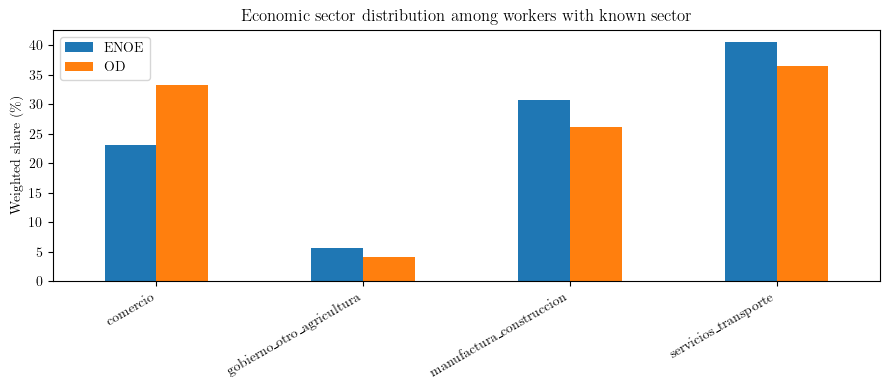

In [28]:
plot_data = sector_comparison.set_index("sector")[["enoe_share", "od_share"]] * 100

ax = plot_data.plot(kind="bar", figsize=(9, 4))
ax.set_xlabel("")
ax.set_ylabel("Weighted share (\%)")
ax.set_title("Economic sector distribution among workers with known sector")
ax.legend(["ENOE", "OD"])
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Conclusions

The main finding is that the informal employment rate, unweighted, is 39.66%, and the weighted rate is 39.26%.

We also see that the distributions are not identical, but they are not completely uncorrelated. The most significant differences appear in employment, education level, municipality, and sector.

For the sector analysis, the weighted percentage of the OD is 30.16%, while for the ENOE it is only 0.56%. In other words, although they accounted for 35.2% of workers in the sample, these cases represent approximately 30% of the expanded population.

That said, it is entirely natural that the next step would be to use a machine learning (ML) model to categorize these cases more accurately. 